# 21. SHAP for one LSTM forecast (Method #1)
We explain **one** forecast of the LSTM trained in notebook 15 — the forecast for **16 August 2007**, the second week of the Global Financial Crisis — with **GradientShap** from the library `captum`.

* **Needs:** `work/model_data.csv` and the model saved by notebook 15 (`work/lstm_2007_seed1.pt` + its two scaling files). **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [ ]:
!pip install -q captum

In [3]:
from pandas import read_csv
dataset = read_csv(folder + 'work/model_data.csv', index_col=0, parse_dates=True)
x = dataset[['ret', 'log_r2', 'us_ret', 'log_us_r2', 'euro_ret', 'log_euro_r2']]
y = dataset['log_rv5_fwd']
print(x.shape)
print(y.shape)

(5243, 6)
(5243,)


In [4]:
fit_days = y.iloc[21:].loc[:'2005-12-31'].dropna().index
fit_days = fit_days[:-5]
val_days = y.loc['2006-01-01':'2006-12-31'].dropna().index
val_days = val_days[:-5]
test_days = y.loc['2007-01-01':'2007-12-31'].dropna().index
print('fitting   :', len(fit_days), 'days,', fit_days[0].date(), 'to', fit_days[-1].date())
print('validation:', len(val_days), 'days,', val_days[0].date(), 'to', val_days[-1].date())
print('test      :', len(test_days), 'days,', test_days[0].date(), 'to', test_days[-1].date())

fitting   : 734 days, 2003-01-31 to 2005-12-21
validation: 248 days, 2006-01-03 to 2006-12-20
test      : 254 days, 2007-01-02 to 2007-12-31


## Load the model of notebook 15
First the blueprint (the same class), then the saved weights and scaling numbers.

In [5]:
import torch
from torch import nn
torch.set_num_threads(2)


class LSTMVol(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)   # 6 inputs, 64 units, 2 layers
        self.drop = nn.Dropout(0.2)
        self.head = nn.Linear(64, 1)                                                # one number out

    def forward(self, x):
        out, _ = self.lstm(x)                  # read the 22 days, one after the other
        last_day = out[:, -1]                  # the memory after the last day
        return self.head(self.drop(last_day)).squeeze(-1)

In [6]:
model = LSTMVol()
model.load_state_dict(torch.load(folder + 'work/lstm_2007_seed1.pt'))
model.eval()
scaling = read_csv(folder + 'work/lstm_2007_seed1_scaling.csv', index_col=0)
x_scaled = (x - scaling['mean']) / scaling['std']
scaling

,mean,std
ret,0.000785,0.008089
log_r2,-11.165465,2.250480
us_ret,0.000468,0.008311
log_us_r2,-11.050012,2.247713
euro_ret,0.000751,0.013503
log_euro_r2,-10.431004,2.421519


## The background (the 'average' situation)
SHAP compares the forecast of our day with forecasts for **typical** situations. As typical situations we take **200 random windows** from the model's own fitting days (2003–2005). `default_rng(...)` with a fixed number makes the random choice repeatable.

In [7]:
from numpy import random, array
fit_positions = []
for day in fit_days:
    fit_positions.append(x.index.get_loc(day))
rng = random.default_rng(1000 * 2007 + 1)
chosen = rng.choice(fit_positions, 200, replace=False)

background = []
for position in chosen:
    background.append(x_scaled.values[position - 21:position + 1])
background = torch.tensor(array(background, dtype='float32'))
print(background.shape)

torch.Size([200, 22, 6])


## The window of the day we explain

In [8]:
from pandas import Timestamp
position = x.index.get_loc(Timestamp('2007-08-16'))
day_window = torch.tensor(array([x_scaled.values[position - 21:position + 1]], dtype='float32'))
print(day_window.shape)

torch.Size([1, 22, 6])


## GradientShap
* **building:** `GradientShap(model)` prepares the explainer for our model;
* **explaining:** `.attribute(...)` returns one contribution for each of the 132 inputs (22 days × 6). It uses `n_samples=1024` random points between the background windows and our day (more samples = more precise).

In [9]:
from captum.attr import GradientShap
torch.manual_seed(1)
random.seed(1)
explainer = GradientShap(model)                                                                   # building
attributions = explainer.attribute(day_window, baselines=background, n_samples=1024, stdevs=0.0)   # explaining
print(attributions.shape)

torch.Size([1, 22, 6])


As a table: one row per day of the window (t-21 = 21 days before, t-0 = the forecast day), one column per input.

In [10]:
from pandas import DataFrame
names = []
for k in range(21, -1, -1):
    names.append('t-' + str(k))
table = DataFrame(attributions[0].detach().numpy(), index=names, columns=x.columns)
table.round(4)

,ret,log_r2,us_ret,log_us_r2,euro_ret,log_euro_r2
t-21,0.0002,0.0005,-0.0002,0.0000,0.0018,0.0006
t-20,-0.0002,0.0010,0.0001,-0.0001,-0.0011,0.0005
t-19,0.0008,0.0025,-0.0005,-0.0004,0.0020,0.0008
t-18,0.0001,-0.0010,0.0000,-0.0001,-0.0008,0.0002
t-17,0.0017,0.0043,-0.0009,-0.0003,0.0031,0.0010
t-16,0.0014,0.0028,0.0001,-0.0002,0.0033,0.0009
t-15,0.0034,0.0046,-0.0020,-0.0002,0.0057,0.0016
t-14,0.0023,0.0043,-0.0020,-0.0003,0.0027,0.0005
t-13,0.0029,0.0042,0.0011,-0.0004,0.0005,-0.0039
t-12,-0.0100,0.0100,-0.0021,0.0005,-0.0064,0.0026


## Do the contributions add up?

In [11]:
with torch.no_grad():
    forecast_day = model(day_window).item()
    average_forecast = model(background).mean().item()
print('forecast - average forecast   =', round(forecast_day - average_forecast, 4))
print('sum of the 132 contributions  =', round(table.values.sum(), 4))

forecast - average forecast   = 0.4862
sum of the 132 contributions  = 0.4698


Very close (GradientShap is an approximation; the gap shrinks with more samples).

## Channel shares — which market was the model listening to?
We take the size of every contribution (`abs`) and add them up for the two inputs of each market.

In [12]:
abs_table = table.abs()
total = abs_table.values.sum()
domestic = (abs_table['ret'].sum() + abs_table['log_r2'].sum()) / total
us = (abs_table['us_ret'].sum() + abs_table['log_us_r2'].sum()) / total
euro = (abs_table['euro_ret'].sum() + abs_table['log_euro_r2'].sum()) / total
print('domestic (ISEQ):', round(domestic, 3))
print('US (S&P 500)   :', round(us, 3))
print('euro (DAX)     :', round(euro, 3))

domestic (ISEQ): 0.499
US (S&P 500)   : 0.282
euro (DAX)     : 0.219


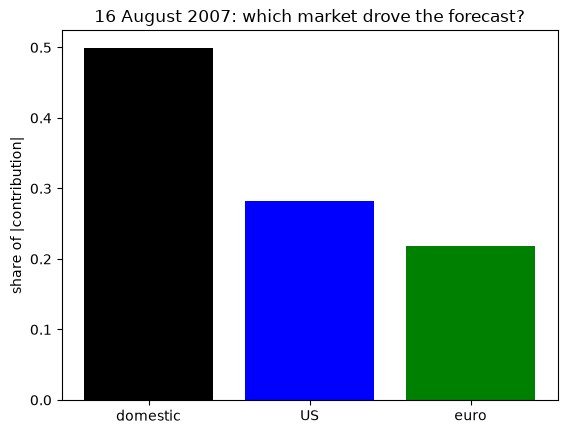

In [13]:
import matplotlib.pyplot as plt
plt.bar(['domestic', 'US', 'euro'], [domestic, us, euro], color=['black', 'blue', 'green'])
plt.ylabel('share of |contribution|')
plt.title('16 August 2007: which market drove the forecast?')
plt.show()

## Direction or size?
Returns show the **direction** of the moves; squared returns their **size**.

In [14]:
direction = (abs_table['ret'].sum() + abs_table['us_ret'].sum() + abs_table['euro_ret'].sum()) / total
size = 1 - direction
print('direction (returns)        :', round(direction, 3))
print('size (squared returns)     :', round(size, 3))

direction (returns)        : 0.66
size (squared returns)     : 0.34


## How far back did the model look?

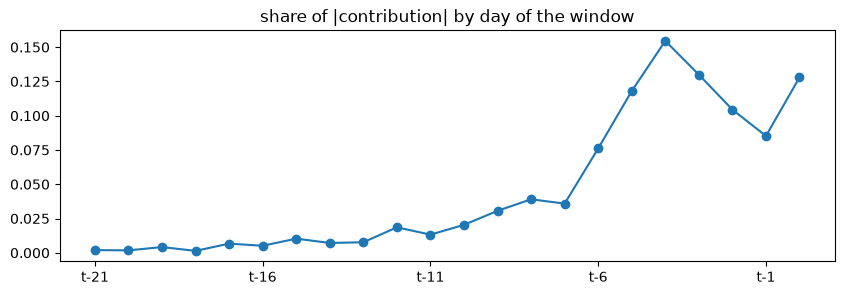

In [15]:
by_day = abs_table.sum(axis=1) / total
by_day.plot(figsize=(10, 3), marker='o', title='share of |contribution| by day of the window')
plt.show()

The Irish market supplies about half of the explanation, the US about 28%, the euro area about 22%. Notebook 22 repeats this for **1,547 days and 5 models per day** and compares the crisis windows with calm times.